<a target="_blank" href="https://colab.research.google.com/github/ZHAW-ZAV/TSO-FS26-students/blob/main/05_linear_regression/05_01_linearRegr.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import sys
import os

IN_COLAB = "google.colab" in sys.modules

file_id_taxifuel = "1Wt3vEust29O4YJtu5nHeuS38Fffp24mo"

if IN_COLAB:
    path_to_taxifuel = "/content/data/taxifuelData.csv"
    os.makedirs(os.path.dirname(path_to_taxifuel), exist_ok=True)
    !gdown "https://drive.google.com/uc?id={file_id_taxifuel}" -O "{path_to_taxifuel}"
else:
    import gdown

    url = f"https://drive.google.com/uc?id={file_id_taxifuel}"
    path_to_taxifuel = "data/taxifuelData.csv"
    os.makedirs(os.path.dirname(path_to_taxifuel), exist_ok=True)
    gdown.download(url, path_to_taxifuel, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Wt3vEust29O4YJtu5nHeuS38Fffp24mo
To: /Users/wate/Documents/GitHub/TSO-FS26-students/05_linear_regression/data/taxifuelData.csv
100%|██████████| 910/910 [00:00<00:00, 1.96MB/s]


In [2]:
# # This code can be used to generate a synthetic dataset of taxi fuel consumption based on taxi duration, 
# # with a more complex relationship and many operational outliers to reflect real-world variability.

# # Set random seed for reproducibility
# np.random.seed(42)

# n = 70  # more flights
# taxi_duration_min = np.random.uniform(4, 40, size=n)

# # Base linear relationship
# base_intercept = 14
# base_slope = 4.1

# # Slight non-linearity (longer taxi routes burn disproportionately more fuel)
# non_linear_term = 0.07 * taxi_duration_min**1.4

# # Increasing variability for longer taxis
# noise = np.random.normal(0, 5 + 0.2 * taxi_duration_min, size=n)

# # Calculate taxi fuel consumption in kg
# taxi_fuel_kg = (
#     base_intercept
#     + base_slope * taxi_duration_min
#     + non_linear_term
#     + noise
# )

# # Create DataFrame
# df = pd.DataFrame({
#     "taxi_duration_min": np.round(taxi_duration_min, 1),
#     "taxi_fuel_kg": np.round(taxi_fuel_kg, 1)
# })

# # -------------------------------------------------
# # Inject MANY operational outliers
# # -------------------------------------------------

# rng = np.random.default_rng(123)

# # High fuel outliers (stop-and-go, congestion, de-icing)
# high_outliers = rng.choice(df.index, size=7, replace=False)
# df.loc[high_outliers, "taxi_fuel_kg"] += rng.uniform(25, 55, size=7)

# # Low fuel outliers (single-engine taxi, efficient routing)
# remaining_idx = df.index.difference(high_outliers)
# low_outliers = rng.choice(remaining_idx, size=5, replace=False)
# df.loc[low_outliers, "taxi_fuel_kg"] -= rng.uniform(20, 40, size=5)

# df.head()

# # # Save to CSV (use if required)
# # df.to_csv('taxifuelData.csv', sep=";", index=False)

The code above loads the data, don't modify.

---------------

***Notebook starts here***

# Linear Regression Models with python (statmodels library)
In the following, we will build a simple linear regression model to predict a target variable $y$ based on a single feature $X$. In order to do so, we will conduct the following steps:
1. Load the data into Python
2. Visualize the data to get a better understanding for the relationship between $X$ and $y$
3. Define the input and output variables of the linear regression model
4. Train the linear regression model
5. Inspect the model
6. Make predictions using the trained model
7. Visualize observations and predictions

### Step 1 — Load the Data into Python

In [23]:
df = pd.read_csv(path_to_taxifuel, delimiter=';')

df.head()

,taxi_duration_min,taxi_fuel_kg
0,17.5,116.148938
1,38.2,190.000000
2,30.4,158.200000
3,25.6,167.997232
4,9.6,49.300000


### Step 2 — Visualize the Relationships

In [24]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["taxi_duration_min"],
        y=df["taxi_fuel_kg"],
        mode="markers",
        name="Flights"
    )
)

fig.update_layout(
    title="Taxi Fuel vs Taxi Duration",
    xaxis_title="Taxi Duration (minutes)",
    yaxis_title="Taxi Fuel Consumption (kg)",
    template="plotly_white"
)

fig.show()

### Step 3 — Define Input (X) and Output (y)

In [25]:
X = df[["taxi_duration_min"]]
y = df["taxi_fuel_kg"]

### Step 4 — Train a Linear Regression Model

In [33]:
import statsmodels.api as sm

# statsmodels does NOT add an intercept automatically
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

### Step 5 — Inspect the Model with `results.summary()` (statsmodels)

When you run a linear regression using the `statsmodels` library in Python, the `results.summary()` function provides a comprehensive overview of the model's performance and the statistical significance of its coefficients. The output of `results.summary()` provides both **model-level performance metrics** and **coefficient-level statistical inference** for a linear regression model.

#### Model-level performance metrics
These three quantities answer **different questions** about a regression model:

- **R²**: *How much of the variability in the data is explained?*
- **Adjusted R²**: *Is this explanatory power meaningful given the number of predictors?*
- **F-statistic**: *Is the model useful at all compared to no model?*


> **R²** measures the fraction of the total variability in the dependent variable that is explained by the regression model.
> 
> $$
> R^2 = 1 - \frac{\text{Residual Sum of Squares (RSS)}}{\text{Total Sum of Squares (TSS)}}
> $$
> 
> - $R^2 = 0$: the model explains no more than predicting the mean
> - $R^2 = 1$: perfect fit
> - Higher $R^2$ indicates better in-sample fit
> 
> **Important:**  
> R² **never decreases** when adding more predictors, even if they are irrelevant.
> 
> **Interpretation example:**  
> An R² of 0.80 means that **80 % of the variation in the output variable is explained by the model**.


> **Adjusted R²** corrects R² for the number of predictors (features) in the model.
> 
> $$
> R^2_{\text{adj}} =
> 1 - (1 - R^2)\frac{n - 1}{n - p - 1}
> $$
> 
> where:
> - $n$ = number of observations  
> - $p$ = number of predictors (features) 
> 
> **Key idea:**  
> Adjusted R² only increases if a new predictor (feature) improves the model **more than would be expected by chance**.
> 
> - Can **decrease** when adding weak or irrelevant variables
> - Useful for comparing models with different numbers of predictors


> The **F-statistic** tests whether the regression model provides a statistically significant improvement over a model with no predictors.
> 
> Null hypothesis:
> $$
> H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0
> $$
> 
> Alternative hypothesis:
> $$
> H_1: \text{At least one } \beta_j \neq 0
> $$
> 
> **Interpretation:**
> - Large F-statistic + small p-value (which means that we can accept the null hypothesis) → the model explains a significant amount of variance
> - Small F-statistic → the model is not better than predicting the mean



### Coefficient-level statistical inference
Coefficient-level statistics help assess the significance and reliability of each predictor (feature) in the model. The coefficient table reports **parameter estimates and statistical tests** for each model term.

| Column | Meaning |
|------|--------|
| `coef` | Estimated regression coefficient $\hat{\beta}$ |
| `std err` | Standard error of the coefficient estimate |
| `t` | t-statistic $\hat{\beta} / \text{std err}$ |
| `P>|t|` | p-value for the test $H_0: \beta = 0$ |
| `[0.025, 0.975]` | 95 % confidence interval for the coefficient |



> #### How to interpret a coefficient
> For a predictor $X_j$ in the model:
> - **`coef`**: Expected change in $Y$ for a one-unit increase in $X_j$, holding all other variables constant. 
> - **`std err`**: Standard error of the coefficient estimate; measures the uncertainty (precision) of `coef`. `std err` answers the question: *If we repeated the study many times, how much would the estimated coefficient vary?*
> - **`t`**: Test statistic for $H_0: \beta_j = 0$; computed as `coef / std err`. The t-statistic answers: “How many standard errors away from zero is this coefficient?”
> - **`P>|t|`**:
>   - small (e.g. < 0.05): statistically significant linear effect of $X_j$ on $Y$, i.e., strong evidence to reject $H_0$.
>   - large: insufficient evidence for a linear relationship, i.e., strong evidence to accept $H_0$.
> - **`[0.025, 0.975]` (95 % CI)** is the 95 % confidence interval for the true coefficient $\beta_j$.
>   - It gives a range of values for $\beta_j$ that are consistent with the data under the model assumptions.
>   - if it includes 0, the effect may not be statistically significant (If zero lies inside the confidence interval, the data do not rule out “no effect”.)
> 
> **Special case: `const`**
> - Represents the **intercept** $\beta_0$
> - Expected value of $Y$ when all predictors are zero
> - Often not physically meaningful, but required mathematically

In [34]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           taxi_fuel_kg   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     390.8
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           6.75e-30
Time:                        14:37:22   Log-Likelihood:                -304.97
No. Observations:                  70   AIC:                             613.9
Df Residuals:                      68   BIC:                             618.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                20.2355      4.94

### Step 6 — Make Predictions

In [35]:
df["predicted_fuel"] = results.predict(X)
df

,taxi_duration_min,taxi_fuel_kg,predicted_fuel
0,17.5,116.148938,93.096291
1,38.2,190.000000,179.280256
2,30.4,158.200000,146.805139
3,25.6,167.997232,126.820451
4,9.6,49.300000,60.204826
...,...,...,...
65,23.5,105.000000,118.077150
66,9.1,60.500000,58.123088
67,32.9,166.800000,157.213830
68,6.7,47.400000,48.130744


###  Step 7 — Visualize Model vs Data

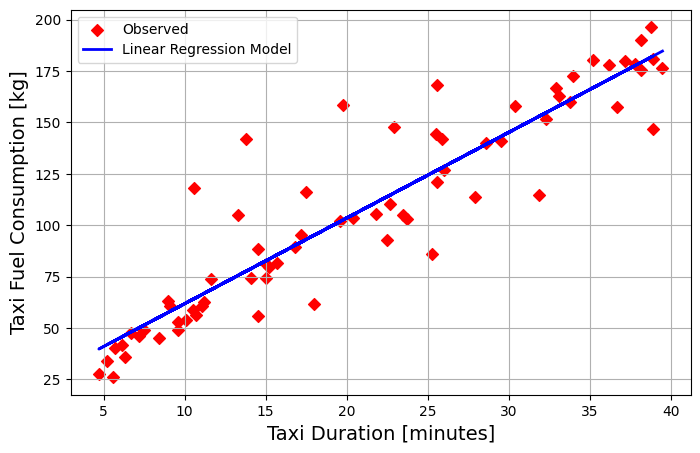

In [9]:
plt.figure(figsize=(8, 5))

filename= "taxi_fuel_linear_regression.pdf"

plot_Residuals = False

# Observed data points
plt.scatter(
    df["taxi_duration_min"],
    df["taxi_fuel_kg"],
    c="r",
    marker="D",          
    label="Observed"
)

# Regression line
plt.plot(
    df["taxi_duration_min"],
    df["predicted_fuel"],
    color="b",
    linewidth=2,
    label="Linear Regression Model"
)

if plot_Residuals:

    filename= "taxi_fuel_linear_regression_with_residuals.pdf"

    # Select indices of the 4 largest absolute residuals
    residual_indices = (
        (df["taxi_fuel_kg"] - df["predicted_fuel"])
        .abs()
        .sort_values(ascending=False)
        .head(4)
        .index
    )

    # Residuals as vertical green lines
    for idx in residual_indices:
        x = df.loc[idx, "taxi_duration_min"]
        y_true = df.loc[idx, "taxi_fuel_kg"]
        y_pred = df.loc[idx, "predicted_fuel"]

        plt.vlines(
            x=x,
            ymin=y_pred,
            ymax=y_true,
            colors="green",
            linestyles="solid",
            linewidth=2,
            alpha=0.9,
            label="Residual" if idx == residual_indices[0] else None
        )

plt.xlabel("Taxi Duration [minutes]", fontsize=14)
plt.ylabel("Taxi Fuel Consumption [kg]", fontsize=14)

plt.legend()
plt.grid(True)

# Save as PDF
plt.savefig(filename, format="pdf", bbox_inches="tight")

plt.show()

### Step 8 — Measure Model Quality (MAE, MSE, R²)

How to explain the output
  - MAE (kg): “On average, our prediction is off by ~X kg of fuel”
  - MSE (kg²): “Penalizes large mistakes more — outliers push this up strongly.”
  - R²: “About Y% of fuel variation is explained by taxi duration

In [10]:
residuals = df["taxi_fuel_kg"] - df["predicted_fuel"]

mae = np.mean(np.abs(residuals))
mse = np.mean(residuals**2)
r2 = results.rsquared

print("MAE (kg):", mae)
print("MSE (kg^2):", mse)
print("R²:", r2)

MAE (kg): 12.685600422504223
MSE (kg^2): 356.19200324596716
R²: 0.8517755732718313


# Multiple Linear Regression Model

### Step 1 — Load the Data into Python

In [37]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# -----------------------------
# 1) Aircraft mass (t)
# -----------------------------
# Narrowbody-like range; adjust if you want a mixed fleet
n = 70
aircraft_mass_ton = rng.uniform(55, 80, size=n)   # tons
aircraft_mass_ton = np.round(aircraft_mass_ton, 1)

# -----------------------------
# 2) Touchdown speed (kt), correlated with mass
# -----------------------------
# Simple, realistic model: heavier -> higher Vref -> higher touchdown speed
# Typical touchdown speeds in the 120–155 kt band

m_ref = 65.0
v_ref_kt = 133.0          # reference touchdown speed around mid-weight
k_v = 0.55                # ~0.55 kt per ton (tunable)
sigma_v = 2.0             # variability from wind, technique, config

touchdown_speed_kt = (
    v_ref_kt
    + k_v * (aircraft_mass_ton - m_ref)
    + rng.normal(0, sigma_v, size=n)
)

# keep within plausible bounds
touchdown_speed_kt = np.clip(touchdown_speed_kt, 120, 155)
touchdown_speed_kt = np.round(touchdown_speed_kt, 1)

# Convert to m/s
v = touchdown_speed_kt * 0.514444

# -----------------------------
# 3) Landing distance model (physics-inspired)
# -----------------------------
# stopping distance ~ V^2 / (2a)
g = 9.81

# Effective deceleration factor (fraction of g)
# Heavier -> slightly reduced effective decel (brake energy/thermal limits)
mu_base = 0.34
k_mu = 0.0013  # per ton above reference (small effect)

mu_eff = mu_base - k_mu * (aircraft_mass_ton - m_ref)
mu_eff = np.clip(mu_eff, 0.24, 0.40)
a = mu_eff * g

# Add "float/flare" distance: increases with speed (pilot technique, flare)
float_distance_m = 120 + 7.0 * (touchdown_speed_kt - 120)

ground_roll_m = (v**2) / (2 * a)

landing_distance_m = float_distance_m + ground_roll_m

# -----------------------------
# 4) Operational noise (uncorrelated with speed AND mass)
# -----------------------------
# Create noise independent of the predictors
noise = rng.normal(0, 55, size=n)  # ~55 m std dev (tunable)
landing_distance_m = landing_distance_m + noise

# -----------------------------
# 5) Optional outliers (rare events)
# -----------------------------
# e.g., long float, late braking, contaminated runway
outlier_idx_high = rng.choice(np.arange(n), size=5, replace=False)
landing_distance_m[outlier_idx_high] += rng.uniform(200, 450, size=5)

outlier_idx_low = rng.choice(np.setdiff1d(np.arange(n), outlier_idx_high), size=2, replace=False)
landing_distance_m[outlier_idx_low] -= rng.uniform(120, 220, size=2)

# -----------------------------
# 6) Build DataFrame
# -----------------------------
df = pd.DataFrame({
    "touchdown_speed_kt": touchdown_speed_kt,
    "aircraft_mass_ton": aircraft_mass_ton,
    "landing_distance_m": np.round(landing_distance_m, 0)
})

df.head()

,touchdown_speed_kt,aircraft_mass_ton,landing_distance_m
0,139.8,74.3,1172.0
1,133.2,66.0,1310.0
2,136.8,76.5,1037.0
3,134.8,72.4,911.0
4,127.0,57.4,674.0


### Step 2 - Visualize Relationships Between Features and Output

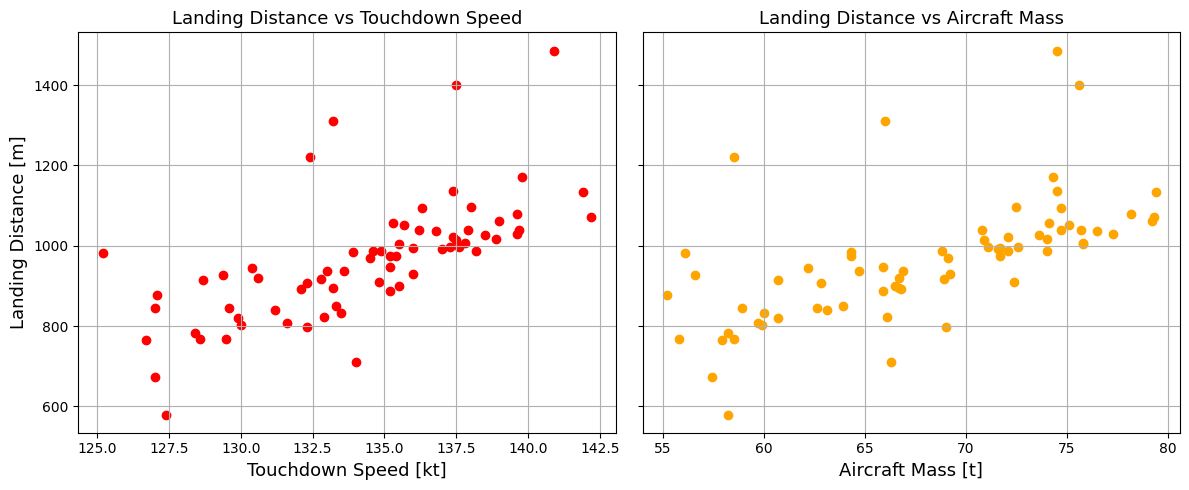

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot 1: Landing distance vs touchdown speed
axes[0].scatter(
    df["touchdown_speed_kt"],
    df["landing_distance_m"],
    color='red',
)
axes[0].set_xlabel("Touchdown Speed [kt]", fontsize=13)
axes[0].set_ylabel("Landing Distance [m]", fontsize=13)
axes[0].set_title("Landing Distance vs Touchdown Speed", fontsize=13)
axes[0].grid(True)

# Plot 2: Landing distance vs aircraft mass
axes[1].scatter(
    df["aircraft_mass_ton"],
    df["landing_distance_m"],
    color="orange",
)
axes[1].set_xlabel("Aircraft Mass [t]", fontsize=13)
axes[1].set_title("Landing Distance vs Aircraft Mass", fontsize=13)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Step 3 - Define Input (X) and Output (y)

In [39]:
X = df[["touchdown_speed_kt", "aircraft_mass_ton"]]
y = df["landing_distance_m"]

# statsmodels does NOT add an intercept automatically
X = sm.add_constant(X)



### Step 4 - Train a Multiple Linear Regression Model

In [40]:
import statsmodels.api as sm

model = sm.OLS(y, X)
results = model.fit()

### Step 5 - Inspect the Model

**Why is the intercept negative?**

In this model, the **intercept does not have a direct physical meaning**.

The linear regression model is:

$$
\text{Landing distance}
=
\beta_0
+ \beta_1 \cdot \text{Touchdown speed}
+ \beta_2 \cdot \text{Aircraft mass}
$$

The **intercept** $\beta_0$ represents the model’s predicted landing distance when **all input variables are zero**:

- Touchdown speed = 0 kt  
- Aircraft mass = 0 t  

These conditions are **not physically realistic** for an aircraft landing.

As a result, the intercept is an **extrapolation outside the range of the data**.  
Its value (even if negative) is simply a mathematical adjustment that allows the model to fit the data well **within the realistic operating range** of speeds and masses.

> **Key takeaway:**  
> A negative intercept does *not* imply a negative landing distance.  
> It means the intercept should not be interpreted physically in this context.

In [41]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     landing_distance_m   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     26.83
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.75e-09
Time:                        16:07:31   Log-Likelihood:                -429.24
No. Observations:                  70   AIC:                             864.5
Df Residuals:                      67   BIC:                             871.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2104.3832    839

### Step 6 - Make Predictions

In [42]:
df["predicted_landing_distance"] = results.predict(X)

### Step 7 - Visualize Model vs Data

To visualize a linear regression model (i.e. the blue line shown in the plots), there are two common approaches.

In the first approach, one input feature is held constant at a fixed value while the other input feature is varied over its full range. The model predictions are then plotted against the varying input. This allows you to clearly see the relationship between the output and a single input feature, conditional on a fixed value of the other feature. The first two plots illustrate this approach.

The second approach is to visualize the model predictions for all observations in the dataset. This can be done as a 2D plot, where only one selected input feature is shown on the x-axis and the predictions are plotted on the y-axis. Alternatively, if the linear regression model has exactly two input features, the predictions can be visualized as a 3D plot, where the regression plane is shown together with the data points (see the plot at the bottom).

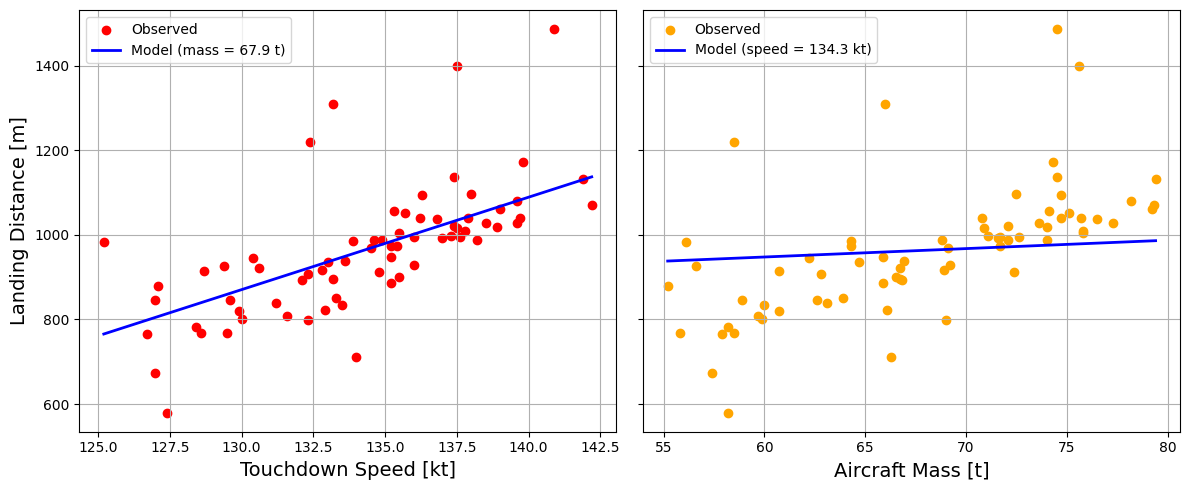

In [ ]:
# Fixed values for conditional model lines
mass_fixed = df["aircraft_mass_ton"].mean()
speed_fixed = df["touchdown_speed_kt"].mean()

# Grids for model lines
speed_grid = np.linspace(df["touchdown_speed_kt"].min(), df["touchdown_speed_kt"].max(), 200)
mass_grid  = np.linspace(df["aircraft_mass_ton"].min(), df["aircraft_mass_ton"].max(), 200)

# Model Variant A: vary speed, fixed mass
X_line_speed = pd.DataFrame({
    "touchdown_speed_kt": speed_grid,
    "aircraft_mass_ton": mass_fixed
})
# Sie müssen, wie schon beim Training ihrem neuen df (X_line_speed in diesem Fall) eine Konstante hinzufügen.
X_line_speed = sm.add_constant(X_line_speed, has_constant='add')
# Danach können Sie eine Prediction machen
y_line_speed = results.predict(X_line_speed)


# Model Variant B: fixed speed, vary mass
X_line_mass = pd.DataFrame({
    "touchdown_speed_kt": speed_fixed,
    "aircraft_mass_ton": mass_grid
})
X_line_mass = sm.add_constant(X_line_mass, has_constant='add')
y_line_mass = results.predict(X_line_mass)

###### PLOTS ######
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---- Left Plot: Distance vs speed ----
axes[0].scatter(
    df["touchdown_speed_kt"],
    df["landing_distance_m"],
    c="r",
    label="Observed"
)

axes[0].plot(
    speed_grid,
    y_line_speed,
    color="b",
    linewidth=2,
    label=f"Model (mass = {mass_fixed:.1f} t)"
)

axes[0].set_xlabel("Touchdown Speed [kt]", fontsize=14)
axes[0].set_ylabel("Landing Distance [m]", fontsize=14)
axes[0].grid(True)

# ---- Right Plot: Distance vs mass ----
axes[1].scatter(
    df["aircraft_mass_ton"],
    df["landing_distance_m"],
    c="orange",
    label="Observed"
)

axes[1].plot(
    mass_grid,
    y_line_mass,
    color="b",
    linewidth=2,
    label=f"Model (speed = {speed_fixed:.1f} kt)"
)

axes[1].set_xlabel("Aircraft Mass [t]", fontsize=14)
axes[1].grid(True)

# Legends (separate per subplot keeps it clear)
axes[0].legend()
axes[1].legend()

plt.tight_layout()

In [46]:
fig = go.Figure()

df = df.sort_values(by="touchdown_speed_kt")

# Observed data points (pre-2020)
fig.add_trace(
    go.Scatter(
        x=df["touchdown_speed_kt"],
        y=df["landing_distance_m"],
        mode="markers",
        name="Observed",
        marker=dict(
            symbol="diamond",
            color="red",
            size=8,
            opacity=0.8
        )
    )
)


# Regression line
fig.add_trace(
    go.Scatter(
        x=df["touchdown_speed_kt"],
        y=df["predicted_landing_distance"],
        mode="lines",
        name="Linear Regression Model",
        line=dict(
            color="blue",
            width=2
        )
    )
)

fig.update_layout(
    title="",
    xaxis_title="Touchdown Speed (knots)",
    yaxis_title="Landing Dostace (meters)",
    template="plotly_white",
    legend=dict(
        font=dict(size=12)
    )
)

fig.update_xaxes(title_font=dict(size=14))
fig.update_yaxes(title_font=dict(size=14))

fig.show()

In [19]:
import plotly.graph_objects as go

# Extract data
x = df["touchdown_speed_kt"].astype(float).to_numpy()
y = df["aircraft_mass_ton"].astype(float).to_numpy()
z = df["landing_distance_m"].astype(float).to_numpy()

# Create grid for plane
x_grid = np.linspace(x.min(), x.max(), 30)
y_grid = np.linspace(y.min(), y.max(), 30)
Xg, Yg = np.meshgrid(x_grid, y_grid)

grid_df = pd.DataFrame({
    "touchdown_speed_kt": Xg.ravel(),
    "aircraft_mass_ton": Yg.ravel()
})

# IMPORTANT: add constant for statsmodels
grid_df_sm = sm.add_constant(grid_df, has_constant="add")

# Predict with statsmodels fitted results (assumes you have `results = sm.OLS(...).fit()`)
Zg = results.predict(grid_df_sm).to_numpy().reshape(Xg.shape)

fig = go.Figure()

# Observed data points
fig.add_trace(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="markers",
        marker=dict(
            size=5,
            symbol="diamond",
            color="red",
            opacity=0.8
        ),
        name="Observed data"
    )
)

# Regression plane
fig.add_trace(
    go.Surface(
        x=Xg,
        y=Yg,
        z=Zg,
        opacity=0.5,
        colorscale="Blues",
        showscale=False,
        name="Linear regression plane"
    )
)

# Layout
fig.update_layout(
    title="Multiple Linear Regression: Landing Distance",
    scene=dict(
        xaxis_title="Touchdown Speed [kt]",
        yaxis_title="Aircraft Mass [t]",
        zaxis_title="Landing Distance [m]",
    ),
    width=900,
    height=650,
)

fig.show()

## Step 8 - Measure Model Quality (MAE, MSE & R²)

In [20]:
residuals = df["landing_distance_m"] - df["predicted_landing_distance"]

mae = np.mean(np.abs(residuals))
mse = np.mean(residuals**2)
r2 = results.rsquared

print("MAE (kg):", mae)
print("MSE (kg^2):", mse)
print("R²:", r2)

MAE (kg): 73.23764189287054
MSE (kg^2): 12408.395400039106
R²: 0.44476191744933413
